In [ ]:
import os

# Make folders for images and masks
os.makedirs('S_BIAD599/images', exist_ok=True)
os.makedirs('S_BIAD599/masks', exist_ok=True)

In [ ]:
import shutil

# Move files into appropriate folders
for filename in os.listdir('/content'):
    if filename.endswith('.tif'):
        if 'seg' in filename.lower():
            shutil.move(filename, f'S_BIAD599/masks/{filename}')
        else:
            shutil.move(filename, f'S_BIAD599/images/{filename}')

In [ ]:
import shutil

# Move files into appropriate folders
for filename in os.listdir('/content'):
    if filename.endswith('.tif'):
        if 'seg' in filename.lower():
            shutil.move(filename, f'S_BIAD599/masks/{filename}')
        else:
            shutil.move(filename, f'S_BIAD599/images/{filename}')

In [ ]:
print("Images:")
print(os.listdir('S_BIAD599/images'))

print("\nMasks:")
print(os.listdir('S_BIAD599/masks'))

Images:
['50A3A129F9_8bit_pea3smFISH.tif', 'E794F7AE68_8bit_lynEGFP.tif', '492B944A71_8bit_lynEGFP.tif', '8C802060C6_8bit_lynEGFP.tif', 'E0EB753C48_8bit_lynEGFP.tif']

Masks:
['9CB73DC13A_8bit_lynEGFP_linUnmix_seg.tif', '9CB73DC13A_8bit_lynEGFP_linUnmix_seg (2).tif', '8C802060C6_8bit_lynEGFP_seg.tif', '9CB73DC13A_8bit_lynEGFP_linUnmix_seg (1).tif', '6B76772EDD_8bit_lynEGFP_seg.tif', '0AF10D7E72_8bit_lynEGFP_seg (1).tif', 'E0EB753C48_8bit_lynEGFP_seg.tif', '0AF10D7E72_8bit_lynEGFP_seg.tif', '673A65D087_8bit_lynEGFP_seg (1).tif', '2902E38204_8bit_lynEGFP_seg.tif', '673A65D087_8bit_lynEGFP_seg.tif']


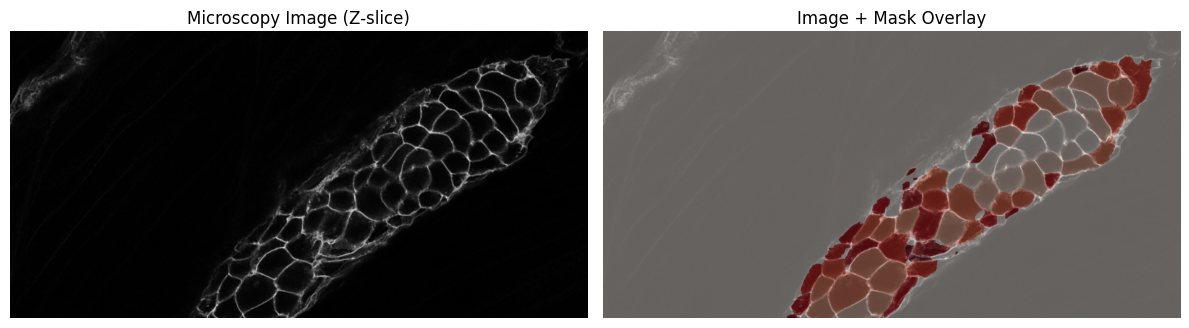

In [ ]:
# Take the middle slice (e.g., Z=56 out of 113)
mid_slice = image.shape[0] // 2
image_2d = image[mid_slice]
mask_2d = mask[mid_slice] if mask.ndim == 3 else mask  # handle 2D masks too

# Now visualize
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(image_2d, cmap='gray')
plt.title("Microscopy Image (Z-slice)")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(image_2d, cmap='gray')
plt.imshow(mask_2d, cmap='Reds', alpha=0.4)
plt.title("Image + Mask Overlay")
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
print("Image shape:", image.shape)
print("Mask shape:", mask.shape)

Image shape: (113, 780, 1572)
Mask shape: (113, 780, 1572)


No mask found for 492B944A71_8bit_lynEGFP.tif — skipping.
No mask found for 50A3A129F9_8bit_pea3smFISH.tif — skipping.


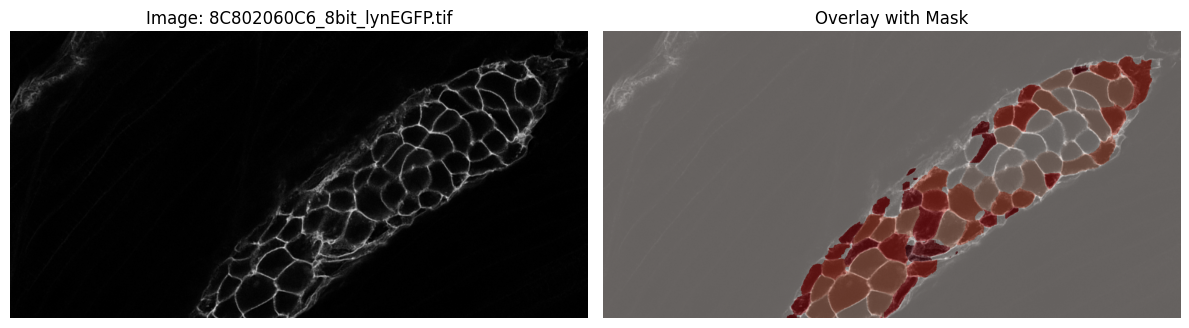

ERROR:tifffile:<tifffile.TiffFile 'E0EB753C48_8bit_lynEGFP.tif'> ImageJ series metadata invalid or corrupted file
ERROR:tifffile:<tifffile.TiffPages @8> invalid page offset 200260161
ERROR:tifffile:<tifffile.TiffFile 'E0EB753C48_8bit_lynEGFP_seg.tif'> ImageJ series metadata invalid or corrupted file
ERROR:tifffile:<tifffile.TiffPages @8> invalid page offset 400507803


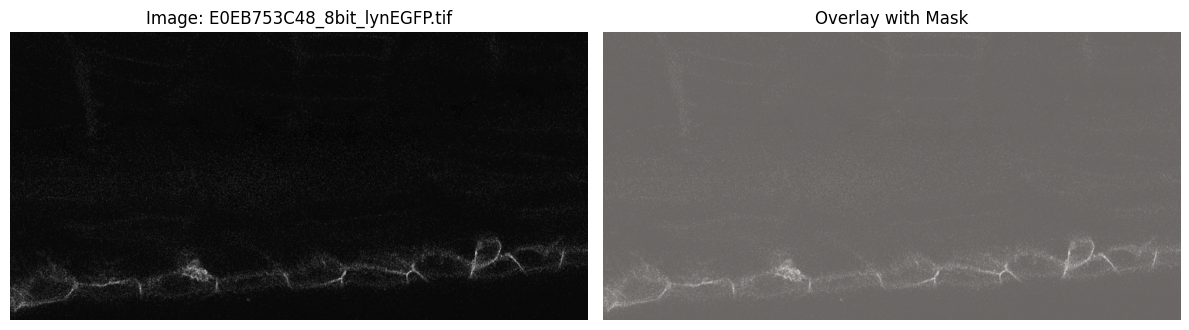

No mask found for E794F7AE68_8bit_lynEGFP.tif — skipping.


In [ ]:
import os
import tifffile as tiff
import matplotlib.pyplot as plt

image_dir = 'S_BIAD599/images'
mask_dir = 'S_BIAD599/masks'

# List files
image_files = sorted([f for f in os.listdir(image_dir) if f.endswith('.tif')])
mask_files = sorted([f for f in os.listdir(mask_dir) if f.endswith('.tif')])

# Loop over image-mask pairs
for img_file in image_files:
    img_prefix = img_file.split('_')[0]  # e.g., 8C802060C6
    # Try to find matching mask
    matching_mask = next((m for m in mask_files if img_prefix in m), None)

    if not matching_mask:
        print(f"No mask found for {img_file} — skipping.")
        continue

    # Load image and mask
    image = tiff.imread(os.path.join(image_dir, img_file))
    mask = tiff.imread(os.path.join(mask_dir, matching_mask))

    # Handle 3D images (Z-stack)
    if image.ndim == 3:
        image_2d = image[image.shape[0] // 2]  # middle slice
    else:
        image_2d = image

    if mask.ndim == 3:
        mask_2d = mask[mask.shape[0] // 2]
    else:
        mask_2d = mask

    # Plot
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.imshow(image_2d, cmap='gray')
    plt.title(f"Image: {img_file}")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(image_2d, cmap='gray')
    plt.imshow(mask_2d, cmap='Reds', alpha=0.4)
    plt.title("Overlay with Mask")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
for img_file in image_files:
    prefix = img_file.split('_')[0]
    matching_mask = next((m for m in mask_files if prefix in m), None)

    if not matching_mask:
        print(f"⛔ Skipping {img_file} — no matching mask.")
        continue
    else:
        print(f"✅ Showing {img_file} + {matching_mask}")


⛔ Skipping 492B944A71_8bit_lynEGFP.tif — no matching mask.
⛔ Skipping 50A3A129F9_8bit_pea3smFISH.tif — no matching mask.
✅ Showing 8C802060C6_8bit_lynEGFP.tif + 8C802060C6_8bit_lynEGFP_seg.tif
✅ Showing E0EB753C48_8bit_lynEGFP.tif + E0EB753C48_8bit_lynEGFP_seg.tif
⛔ Skipping E794F7AE68_8bit_lynEGFP.tif — no matching mask.


In [ ]:
!pip install cellpose[all] tifffile matplotlib scikit-image

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.4/149.4 kB 5.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 5.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 62.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 34.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 40.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.4 MB/s eta 0:00:00
   

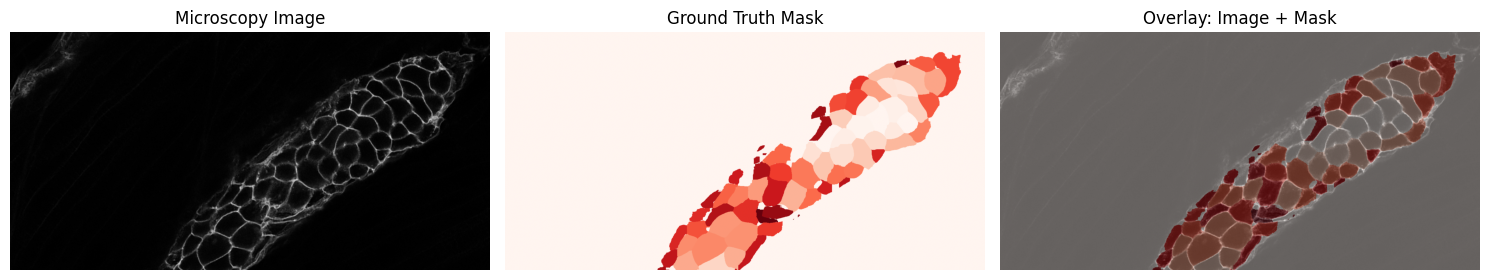

In [ ]:
import tifffile as tiff
import matplotlib.pyplot as plt
import os
import numpy as np

# File paths
image_path = 'S_BIAD599/images/8C802060C6_8bit_lynEGFP.tif'
mask_path  = 'S_BIAD599/masks/8C802060C6_8bit_lynEGFP_seg.tif'

# Load 3D image and mask, select middle Z-slice
image_3d = tiff.imread(image_path)
mask_3d  = tiff.imread(mask_path)

z = image_3d.shape[0] // 2
image_2d = image_3d[z]
mask_2d  = mask_3d[z] if mask_3d.ndim == 3 else mask_3d

# ✅ Display image, mask, and overlay
plt.figure(figsize=(15, 5))

# Image only
plt.subplot(1, 3, 1)
plt.imshow(image_2d, cmap='gray')
plt.title("Microscopy Image")
plt.axis('off')

# Mask only
plt.subplot(1, 3, 2)
plt.imshow(mask_2d, cmap='Reds')
plt.title("Ground Truth Mask")
plt.axis('off')

# Overlay
plt.subplot(1, 3, 3)
plt.imshow(image_2d, cmap='gray')
plt.imshow(mask_2d, cmap='Reds', alpha=0.4)
plt.title("Overlay: Image + Mask")
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
!pip install cellpose==2.2.1

In [ ]:
from cellpose import models
import tifffile as tiff
import numpy as np
import matplotlib.pyplot as plt

# Load image
image_path = 'S_BIAD599/images/8C802060C6_8bit_lynEGFP.tif'
image_3d = tiff.imread(image_path)
z = image_3d.shape[0] // 2
image_2d = image_3d[z]

# Load Cellpose model and run prediction
model = models.CellposeModel(gpu=False, model_type='cyto')
masks, flows, styles = model.eval(image_2d, diameter=None, channels=[0, 0])

100%|██████████| 25.3M/25.3M [00:00<00:00, 32.7MB/s]


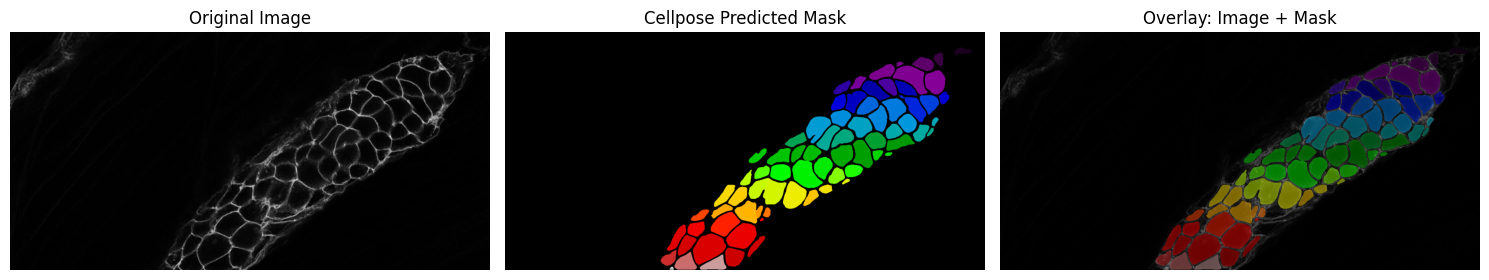

In [ ]:
plt.figure(figsize=(15, 5))

# Show original image
plt.subplot(1, 3, 1)
plt.imshow(image_2d, cmap='gray')
plt.title("Original Image")
plt.axis('off')

# Show Cellpose mask
plt.subplot(1, 3, 2)
plt.imshow(masks, cmap='nipy_spectral')
plt.title("Cellpose Predicted Mask")
plt.axis('off')

# Overlay
plt.subplot(1, 3, 3)
plt.imshow(image_2d, cmap='gray')
plt.imshow(masks, cmap='nipy_spectral', alpha=0.5)
plt.title("Overlay: Image + Mask")
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import jaccard_score, f1_score
import tifffile as tiff

# Load ground truth mask
mask_path = 'S_BIAD599/masks/8C802060C6_8bit_lynEGFP_seg.tif'
mask_3d = tiff.imread(mask_path)
gt_mask_2d = mask_3d[z] if mask_3d.ndim == 3 else mask_3d

# Flatten masks
y_true = gt_mask_2d.flatten()
y_pred = masks.flatten()

# Convert to binary (foreground = 1)
y_true_bin = (y_true > 0).astype(int)
y_pred_bin = (y_pred > 0).astype(int)

# Calculate Dice and IoU
dice = f1_score(y_true_bin, y_pred_bin)
iou = jaccard_score(y_true_bin, y_pred_bin)

print(f"Dice Score: {dice:.4f}")
print(f"IoU Score: {iou:.4f}")

Dice Score: 0.7830
IoU Score: 0.6433


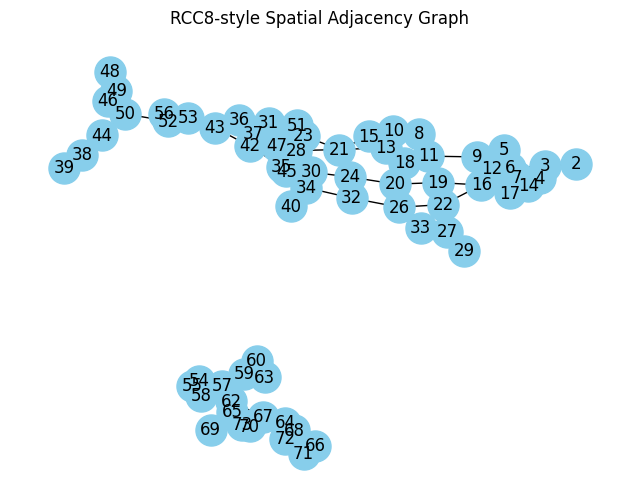

In [ ]:
from skimage.measure import label, regionprops
import networkx as nx
import matplotlib.pyplot as plt

# Label Cellpose segments
labeled = label(masks)
props = regionprops(labeled)
G = nx.Graph()

# Build edges for adjacent/overlapping regions
for i, region1 in enumerate(props):
    for j, region2 in enumerate(props[i+1:], i+1):
        minr1, minc1, maxr1, maxc1 = region1.bbox
        minr2, minc2, maxr2, maxc2 = region2.bbox
        if maxr1 >= minr2 and minr1 <= maxr2 and maxc1 >= minc2 and minc1 <= maxc2:
            G.add_edge(region1.label, region2.label)

# Visualize adjacency graph
plt.figure(figsize=(8,6))
nx.draw_networkx(G, with_labels=True, node_color='skyblue', node_size=500)
plt.title("RCC8-style Spatial Adjacency Graph")
plt.axis('off')
plt.show()

In [ ]:
from skimage.measure import label, regionprops
from shapely.geometry import Polygon
import shapely

def mask_to_polygons(mask):
    from skimage import measure
    contours = measure.find_contours(mask, 0.5)
    return [Polygon(c) for c in contours if len(c) >= 3]

# Label Cellpose and Ground Truth
cp_labeled = label(masks)
gt_labeled = label(gt_mask_2d)

In [ ]:
rcc8_counts = {
    "DC": 0, "EC": 0, "PO": 0, "TPP": 0, "NTPP": 0,
    "TPPi": 0, "NTPPi": 0, "EQ": 0
}

# Compare each CP object vs GT object
for cp_region in regionprops(cp_labeled):
    cp_mask = (cp_labeled == cp_region.label).astype(np.uint8)
    cp_poly = mask_to_polygons(cp_mask)
    if not cp_poly:
        continue
    cp_poly = cp_poly[0]

    for gt_region in regionprops(gt_labeled):
        gt_mask = (gt_labeled == gt_region.label).astype(np.uint8)
        gt_poly = mask_to_polygons(gt_mask)
        if not gt_poly:
            continue
        gt_poly = gt_poly[0]

        # RCC8 classification logic
        if cp_poly.equals(gt_poly):
            rcc8_counts["EQ"] += 1
        elif cp_poly.disjoint(gt_poly):
            rcc8_counts["DC"] += 1
        elif cp_poly.touches(gt_poly):
            rcc8_counts["EC"] += 1
        elif cp_poly.within(gt_poly):
            if cp_poly.touches(gt_poly):
                rcc8_counts["TPP"] += 1
            else:
                rcc8_counts["NTPP"] += 1
        elif gt_poly.within(cp_poly):
            if gt_poly.touches(cp_poly):
                rcc8_counts["TPPi"] += 1
            else:
                rcc8_counts["NTPPi"] += 1
        elif cp_poly.overlaps(gt_poly):
            rcc8_counts["PO"] += 1

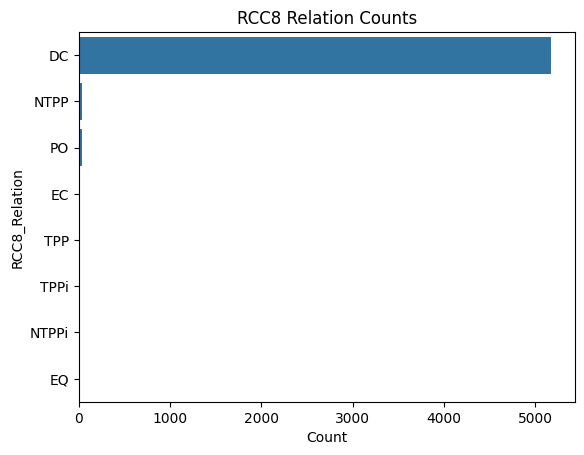

In [ ]:
import pandas as pd

rcc8_df = pd.DataFrame(list(rcc8_counts.items()), columns=["RCC8_Relation", "Count"])
rcc8_df.sort_values("Count", ascending=False, inplace=True)
import seaborn as sns
sns.barplot(x='Count', y='RCC8_Relation', data=rcc8_df).set(title="RCC8 Relation Counts")
plt.show()